In [47]:
# Bibliotecas básicas
import mlflow
import pandas as pd
import numpy as np

import warnings

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats

In [48]:
mlflow.set_tracking_uri("sqlite:///../data/mlflow/churn_experiments.db")

In [49]:
df = pd.read_csv('../data/dataset/telco_customer_churn.csv')

print(f"Formato dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
df.head(10)

Formato dos dados: (7043, 21)

Primeiras linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [50]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [51]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

=== ANÁLISE DE MISSING VALUES ===

Nenhum missing value detectado!


=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Sem churn (0): 73.46%
Com churn (1): 26.54%


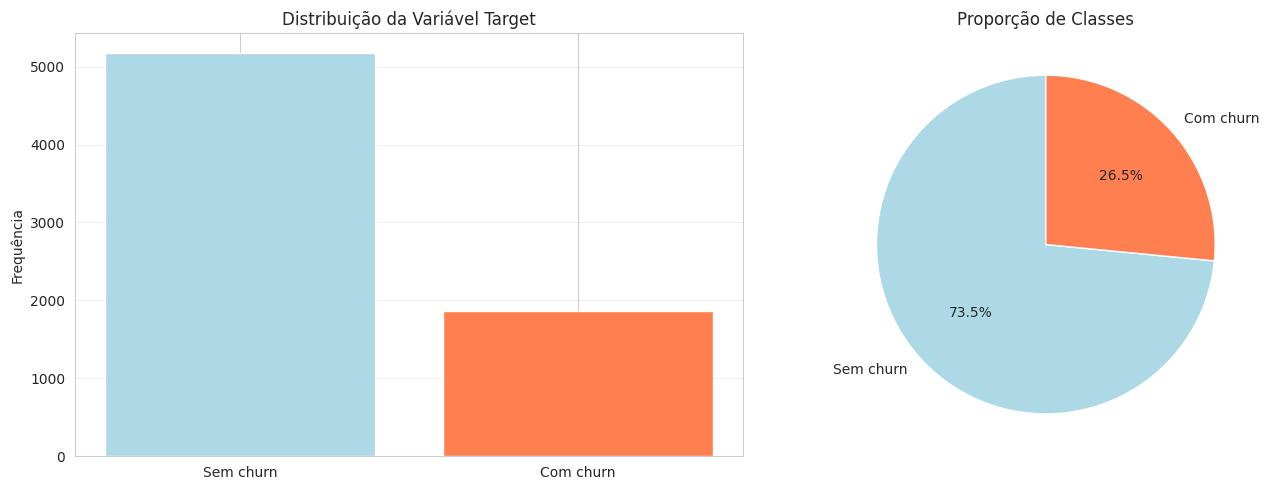


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [52]:
df.rename(columns={'Churn': 'target'}, inplace=True)

# Converter target para binário (0 = sem churn, 1 = com churn)
df['target'] = df['target'].map({'Yes': 1, 'No': 0})

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Sem churn" if idx == 0 else "Com churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Sem churn', 'Com churn'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Sem churn', 'Com churn'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")